In [1]:
import time
import sys
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from line_profiler import profile
import logging
import time
import joblib 

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn import set_config
set_config(transform_output = "pandas")

from captum.attr import IntegratedGradients, LayerConductance, NeuronConductance
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset, IterableDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter
# default `log_dir` is "runs" - we'll be more specific here
writer = SummaryWriter('runs/kags4e7')

import gc
torch.cuda.empty_cache()
gc.collect()

31

In [ ]:
def prep_data(load_path, save_path, train=True):
    df = pd.read_csv(load_path) 
    print(df.info())

    # Data prep
    # Basic data mod of train data
    df = df.drop(columns=['id'])
    df['Gender'] = df.Gender.replace({"Female":0, 'Male':1}).astype(np.int8)
    df['Vehicle_Age'] = df.Vehicle_Age.replace({'< 1 Year':0, '1-2 Year':1, '> 2 Years':2}).astype(np.int8)
    df['Vehicle_Damage']  = df.Vehicle_Damage.replace({'No':0, 'Yes':1}).astype(np.int8)

    list_int = ['Vehicle_Age','Vintage','Policy_Sales_Channel','Region_Code']
    list_bool = ['Driving_License', 'Previously_Insured', 'Vehicle_Damage', 'Gender']
    list_float = ['Annual_Premium','Age']
    list_target = ['Response']

    df[list_int] = df[list_int].astype(np.int32)
    # Optimize integer columns
    if train:
        int_columns = list_int + list_bool + list_target
    else:
        int_columns = list_int + list_bool
        
    for col in int_columns:
        col_min = df[col].min()
        col_max = df[col].max()
        if col_min >= -128 and col_max <= 127:
            df[col] = df[col].astype(np.int8)
        elif col_min >= -32768 and col_max <= 32767:
            df[col] = df[col].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            df[col] = df[col].astype(np.int32)

    df[list_float] = df[list_float].astype(np.float)

    print(df.info())
    df.to_parquet(save_path)
    del df
    return 

prep_data('data/raw/train.csv', 'data/artifacts/train.parquet')
# 1+ GB -> 209 MB
#prep_data('data/raw/test.csv', 'data/artifacts/test.parquet', train=False)
# 644 MB -> 132 MB

In [ ]:
def save_small(path_load, path_save):
    
    df = pd.read_parquet(path_load)
    vc = df.Response.value_counts()
    print(vc[1]/vc[0])
    y = df.pop("Response")
    
    Xtrain,_,ytrain,_ = train_test_split(df, y, train_size=int(1e5), stratify=y)
    del df, y
    
    vc = ytrain.value_counts()
    print(vc[1]/vc[0])
    
    df_small = pd.concat([Xtrain, ytrain], axis=1)
    df_small.to_parquet(path_save)
    return

save_small('data/artifacts/train.parquet','data/artifacts/train_small.parquet')

In [2]:
class Model(nn.Module):
    def __init__(self, in_features, h1=20, h2=30,d_out=2):
        super().__init__()
        
        self.fc1 = nn.Linear(in_features, h1)
        self.relu1 = nn.SiLU()
        self.bn1 = nn.BatchNorm1d(h1)
        self.dp1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(h1, h2)
        self.relu2 = nn.SiLU()
        self.bn2 = nn.BatchNorm1d(h2)
        self.dp2 = nn.Dropout(0.1)

        self.out = nn.Linear(h2,d_out)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.bn1(x)
        x = self.dp1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.bn2(x)
        x = self.dp2(x)
        x = self.out(x)
        return x

In [3]:
class InsDataset(Dataset):
    def __init__(self, dfX, dfy):
        self.dfy = torch.tensor(dfy.values, dtype=torch.long)
        self.dfX = torch.tensor(dfX.values, dtype=torch.float32)
                 
    def __len__(self):
        return len(self.dfy)
    
    @profile
    def __getitem__(self,idx, batch_size):
        features = self.dfX[idx:idx+batch_size,:]
        label    = self.dfy[idx:idx+batch_size]
        return [features, label]

class FastDataLoader:
    def __init__(self, ds, batch_size=32):

        self.ds = ds
        self.dataset_len = ds.__len__()
        self.batch_size = batch_size

        # Calculate # batches
        n_batches, remainder = divmod(self.dataset_len, self.batch_size)
        if remainder > 0:
            n_batches += 1
        self.n_batches = n_batches
        
    def __iter__(self):
        self.i = 0
        return self

    @profile
    def __next__(self):
        if self.i >= self.dataset_len:
            raise StopIteration
        batch = self.ds.__getitem__(self.i, self.batch_size)
        self.i += self.batch_size
        return batch

    def __len__(self):
        return self.n_batches

In [4]:
BATCH_SIZE = 1000

def load_data(path_load, batch_size):
    df = pd.read_parquet(path_load)
    y = df.pop('Response')
    
    list_int = ['Vehicle_Age','Vintage','Policy_Sales_Channel','Region_Code']
    list_bool = ['Driving_License', 'Previously_Insured', 'Vehicle_Damage', 'Gender']
    list_float = ['Annual_Premium','Age']
    list_target = ['Response']
    
    # Calc imbalance
    class_no = pd.DataFrame(y.to_numpy()).value_counts()/len(y)
    #print(class_no)
    no_features = df.shape[1]
    
    Xtrain, Xtest, ytrain, ytest = train_test_split(df, y, test_size=0.1, stratify=y)
    
    scaler = StandardScaler()
    Xtrain.loc[:,list_float] = scaler.fit_transform(Xtrain.loc[:, list_float])
    Xtest.loc[:,list_float] = scaler.transform(Xtest.loc[:,list_float])
    
    train_dataset = InsDataset(Xtrain, ytrain)
    test_dataset = InsDataset(Xtest, ytest)
    
    trainloader = FastDataLoader(train_dataset, batch_size=batch_size)
    testloader = FastDataLoader(test_dataset, batch_size=batch_size)
    
    return trainloader, testloader, Xtest, ytest, class_no, no_features

trainloader, testloader, Xtest, ytest, class_no, no_features = \
    load_data('data/artifacts/train_small.parquet', BATCH_SIZE)
    

In [5]:
LR = 1e-4
EPOCHS = 101

def train(trainloader, testloader, class_no, no_features, lr, epochs, 
          proc_device='cpu', verbose=True):
    
    # Device selection
    device = torch.device(proc_device) #('cuda:0' if torch.cuda.is_available() else 'cpu')
    # Def model
    in_features, h1, h2 = no_features, 2*no_features, no_features
    model = Model(in_features, h1, h2).to(device)
    # Set metric (criterion) and choose optimizer
    class_weights = torch.FloatTensor(1 - class_no.values).to(device)
    criterion = nn.CrossEntropyLoss(weight = class_weights).to(device)
    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) #, weight_decay=w_decay)
    
    # Training metrics
    train_loss_per_epoch = []
    test_loss_per_epoch = []
    
    for epoch in range(epochs):
        
        model.train()
        running_loss = 0.0
        for i, (features, label) in enumerate(trainloader):
            features = features.to(device)
            label = label.to(device)

            # Reset gradient
            optimizer.zero_grad()
        
            # Forward, backward, optimize
            outputs = model.forward(features)
            loss = criterion(outputs, torch.flatten(label))
            loss.backward()
            optimizer.step()
            
            # Metrics
            running_loss += loss.item()
        
        # Sum single epoch metrics
        train_loss_per_epoch.append(running_loss / (i+1))
        running_loss = 0.0
        
        running_test_loss = 0.0
        model.eval()
        for i, (features, label) in enumerate(testloader):
            features = features.to(device)
            label = label.to(device)
            
            y_pred = model.forward(features)
            loss = criterion(y_pred, torch.flatten(label)).detach()
            running_test_loss += loss.item()
            
        # Sum singe epoch test metrics
        test_loss_per_epoch.append(running_test_loss / (i+1))
        running_test_loss = 0.0

        if verbose:
            if epoch % 10 == 0:
                print(f"Ep: {epoch} Loss Training: {train_loss_per_epoch[-1]} Test: {test_loss_per_epoch[-1]}")
        else:
            if epoch == (epochs - 1):
                print(f'trained on: {proc_device}')
                print(f"Ep: {epoch} Loss Training: {train_loss_per_epoch[-1]} Test: {test_loss_per_epoch[-1]}")
    
    return model, train_loss_per_epoch, test_loss_per_epoch

trained_model, train_loss_per_epoch, test_loss_per_epoch = \
    train(trainloader, testloader, class_no, no_features, LR, EPOCHS)
  
  

Ep: 0 Loss Training: 0.730515984694163 Test: 0.6888628304004669
Ep: 10 Loss Training: 0.6720411128467983 Test: 0.6598677635192871
Ep: 20 Loss Training: 0.6004356172349717 Test: 0.5834712624549866
Ep: 30 Loss Training: 0.5286588148938285 Test: 0.4906409740447998
Ep: 40 Loss Training: 0.5099567241138883 Test: 0.4651578217744827
Ep: 50 Loss Training: 0.4850987652937571 Test: 0.45294898450374604
Ep: 60 Loss Training: 0.4749033653073841 Test: 0.445907461643219
Ep: 70 Loss Training: 0.4698398255639606 Test: 0.4426616966724396
Ep: 80 Loss Training: 0.46453148755762314 Test: 0.44046410322189333
Ep: 90 Loss Training: 0.4609470850891537 Test: 0.4391831994056702


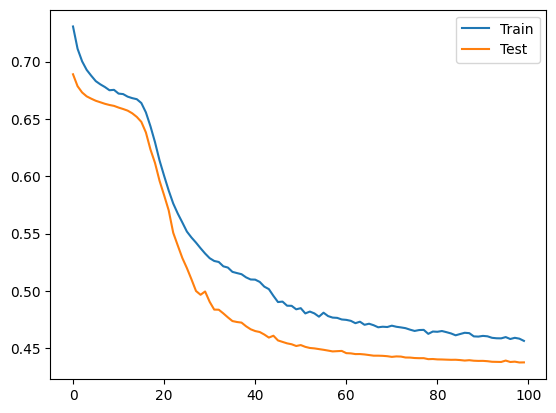

In [6]:
def plot_training(epochs, train_loss_per_epoch, test_loss_per_epoch):
    plt.figure()
    plt.plot(np.arange(epochs), train_loss_per_epoch, label="Train")
    plt.plot(np.arange(epochs), test_loss_per_epoch, label='Test')
    plt.legend()
    plt.show()
    return

plot_training(EPOCHS, train_loss_per_epoch, test_loss_per_epoch)

In [7]:
# Predict test set
trained_model.eval()
Xtest_tensor = torch.tensor(Xtest.values, dtype=torch.float)
y_pred = trained_model.forward(Xtest_tensor)
y_hat = torch.argmax(y_pred, 1).detach().cpu().numpy()

proba_layer = nn.Softmax(dim=1)
y_pred_proba = proba_layer(y_pred)
y_pred_proba_arr = y_pred_proba.detach().cpu().numpy()

print(confusion_matrix(ytest, y_hat))
print(classification_report(ytest, y_hat))
print("Accuracy: ", accuracy_score(ytest, y_hat))
print("ROC AUC:", roc_auc_score(ytest, y_pred_proba_arr[:,1]))


[[5473 3297]
 [  60 1170]]
              precision    recall  f1-score   support

           0       0.99      0.62      0.77      8770
           1       0.26      0.95      0.41      1230

    accuracy                           0.66     10000
   macro avg       0.63      0.79      0.59     10000
weighted avg       0.90      0.66      0.72     10000

Accuracy:  0.6643
ROC AUC: 0.8380492440044126


In [8]:
# Compare cpu and gpu
start_time = time.time()
_,_,_ = train(trainloader, testloader, class_no, no_features, LR, EPOCHS, 
              proc_device='cpu', verbose=False)
print(f'Training time: ', time.time() - start_time)

start_time = time.time()
_,_,_ = train(trainloader, testloader, class_no, no_features, LR, EPOCHS, 
              proc_device='cuda:0', verbose=False)
print(f'Training time: ', time.time() - start_time)

trained on: cpu
Ep: 99 Loss Training: 0.4474476036098268 Test: 0.43360355496406555
Training time:  27.181807041168213
trained on: cuda:0
Ep: 99 Loss Training: 0.45072692301538253 Test: 0.43368316292762754
Training time:  42.760740756988525


In [19]:
%who DataFrame
%who torch.Tensor
gc.collect()

Xtest	 
No variables match your requested type.


1646

In [20]:
BATCH_SIZE = 25000
trainloader, testloader, Xtest, ytest, class_no, no_features = \
    load_data('data/artifacts/train.parquet', BATCH_SIZE)

start_time = time.time()
_,_,_ = train(trainloader, testloader, class_no, no_features, LR, EPOCHS, 
              proc_device='cpu', verbose=True)
print(f'Training time: ', time.time() - start_time)

start_time = time.time()
_,_,_ = train(trainloader, testloader, class_no, no_features, LR, EPOCHS, 
              proc_device='cuda:0', verbose=True)
print(f'Training time: ', time.time() - start_time)

Ep: 0 Loss Training: 0.6876649636820138 Test: 0.6623582954102374
Ep: 10 Loss Training: 0.44612914984484753 Test: 0.4281558026658728
Ep: 20 Loss Training: 0.4324656025472894 Test: 0.422579419105611
Ep: 30 Loss Training: 0.42890556576740313 Test: 0.4221114624053874
Ep: 40 Loss Training: 0.4269332390233695 Test: 0.4209849415941441
Ep: 50 Loss Training: 0.4260871002473027 Test: 0.42053187781191886
Ep: 60 Loss Training: 0.4256653357701129 Test: 0.42031199881371034
Ep: 70 Loss Training: 0.425297283623592 Test: 0.42047316787090705
Ep: 80 Loss Training: 0.42494052332567883 Test: 0.4202631096890632
Ep: 90 Loss Training: 0.42460178323538905 Test: 0.4200825355154403
Training time:  722.1593248844147
Ep: 0 Loss Training: 0.7324609884296555 Test: 0.6730363571897466
Ep: 10 Loss Training: 0.4629403840346509 Test: 0.43750485714445725
Ep: 20 Loss Training: 0.436349391865443 Test: 0.42410225754088543
Ep: 30 Loss Training: 0.4310159462044038 Test: 0.42260927659399966
Ep: 40 Loss Training: 0.4280972724219